In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from plot import make_theme, plot_image, interp

%matplotlib inline
plt.rcParams['font.size'] = 7

In [2]:
def plot_label(ax, count, x=0, y=1.03, color='k'):
    ax.text(x, y, count, fontdict=dict(fontsize=9), transform=ax.transAxes, color=color, weight='bold')

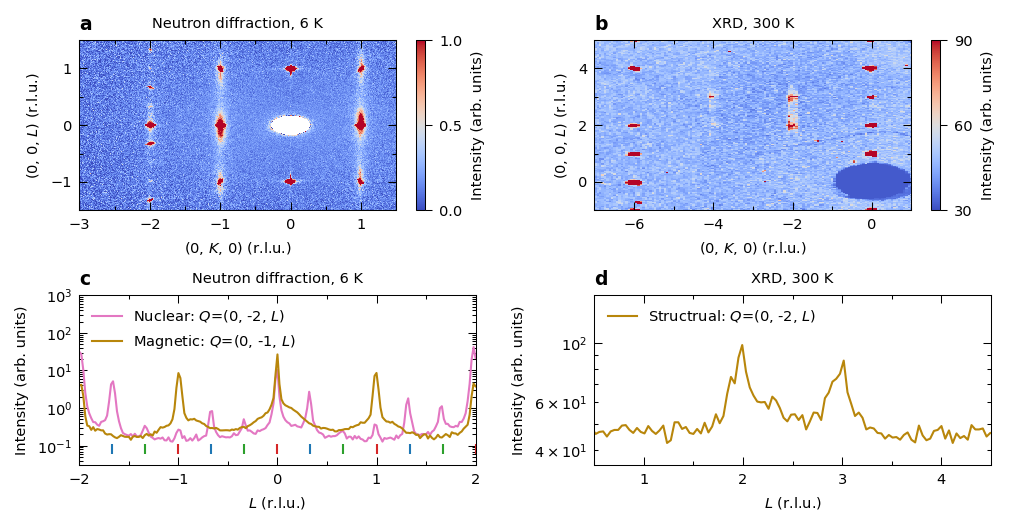

In [3]:
fig, axs = plt.subplots(2, 2, figsize=(6.75,6.75/2), dpi=150, gridspec_kw=dict(
    wspace=0.3, hspace=0.5, top=0.94, bottom=0.1, left=0.08, right=0.98))
# cax = fig.add_axes([0.505, 0.32, 0.01, 0.4])
cmap = 'coolwarm'

# neutron
## colorplot
ax = axs[0,0]
data = dict(np.load('../corelli/HEPS3_0KL_006K.npz'))
### plot
choosex = np.logical_and(data['Krlu']>=-3.1, data['Krlu']<=1.6)
choosey = np.abs(data['Lrlu'])<=1.6
_, _, cbar = plot_image(data['I'][choosey,:][:,choosex], x=data['Krlu'][choosex], y=data['Lrlu'][choosey],
                        ax=ax, cbar=True, cmap=cmap, vmin=0., vmax=1)
### config
make_theme(ax, ticklength=4)
ax.set_xlim(-3,1.5)
ax.set_xticks(np.arange(-3.,1.01,1.))
ax.set_xlabel('(0, $K$, 0) (r.l.u.)')
ax.set_ylim(-1.5,1.5)
ax.set_yticks(np.arange(-1.,1.01,1.))
ax.set_ylabel('(0, 0, $L$) (r.l.u.)')
ax.set_title('Neutron diffraction, 6 K', fontsize=7)
plot_label(ax, 'a', x=0, y=1.06)
### colorbar
cbar.set_label('Intensity (arb. units)')
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(width=0.5)
cbar.set_ticks([0.,0.5,1])

## Lcut
ax = axs[1,0]
data = dict(np.load('../corelli/HEPS3_HKL_006K.npz'))
dHKL = [0.02,0.04,2.]
### nuclear
HKL = [0.,2.,0.]
chooseH = np.abs(data['Hrlu']-HKL[0])<=dHKL[0]
chooseK = np.abs(data['Krlu']-HKL[1])<=dHKL[1]
chooseL = np.abs(data['Lrlu']-HKL[2])<=dHKL[2]
cut1 = dict(x=data['Lrlu'][chooseL], y=data['I'][chooseL,:,:][:,chooseK,:][:,:,chooseH].mean(axis=(1,2)))
### magnetic 
HKL = [0.,1.,0.]
chooseH = np.abs(data['Hrlu']-HKL[0])<=dHKL[0]
chooseK = np.abs(data['Krlu']-HKL[1])<=dHKL[1]
chooseL = np.abs(data['Lrlu']-HKL[2])<=dHKL[2]
cut2 = dict(x=data['Lrlu'][chooseL], y=data['I'][chooseL,:,:][:,chooseK,:][:,:,chooseH].mean(axis=(1,2)))
### plot
ax.plot(cut1['x'], cut1['y'], color='C6', lw=1, label='Nuclear: $Q$=(0, -2, $L$)')
ax.plot(cut2['x'], cut2['y'], color='darkgoldenrod', lw=1, label='Magnetic: $Q$=(0, -1, $L$)')
### config
make_theme(ax, ticklength=4)
ax.legend(frameon=False, loc='upper left')
ax.set_yscale('log')
ax.set_xlim(-2,2)
ax.set_xticks(np.arange(-2,2.01,1.))
ax.set_xlabel('$L$ (r.l.u.)')
ax.set_ylim(0.03,1000)
ax.set_ylabel('Intensity (arb. units)')
ax.set_title('Neutron diffraction, 6 K', fontsize=7)
plot_label(ax, 'c', x=0, y=1.06)

# xrd
## colorplot
ax  =axs[0,1]
data = dict(np.load('../others/q_0kl.npz'))
### plot
choosex = np.logical_and(data['x']>=-7.1, data['x']<=1.6)
choosey = np.logical_and(data['y']>=-1.1, data['y']<=5.1)
I = data['I'][choosey,:][:,choosex] + 0.
_, _, cbar = plot_image(I, x=data['x'][choosex], y=data['y'][choosey],
                        ax=ax, cbar=True, cmap=cmap, vmin=30., vmax=90)
### config
make_theme(ax, ticklength=4)
ax.set_xlim(-7,1)
ax.set_xticks(np.arange(-6,0.01,2.))
ax.set_xlabel('(0, $K$, 0) (r.l.u.)')
ax.set_ylim(-1,5)
ax.set_yticks(np.arange(0.,4.1,2.))
ax.set_ylabel('(0, 0, $L$) (r.l.u.)')
ax.set_title('XRD, 300 K', fontsize=7)
plot_label(ax, 'b', x=0, y=1.06)
### colorbar
cbar.set_label('Intensity (arb. units)')
cbar.outline.set_linewidth(0.5)
cbar.ax.tick_params(width=0.5)
cbar.set_ticks([30,60,90])

## Lcut
ax = axs[1,1]
data = dict(np.load('../others/q_0kl.npz'))
choosex = np.abs(data['x']+2.)<=0.15
choosey = np.logical_and(data['y']>=0, data['y']<=5)
### plot
ax.plot(data['y'][choosey], data['I'][choosey,:][:,choosex].mean(axis=1), color='darkgoldenrod', lw=1, label='Structrual: $Q$=(0, -2, $L$)')
### config
make_theme(ax, ticklength=4)
ax.legend(frameon=False, loc='upper left')
ax.set_yscale('log')
ax.set_xlim(0.5,4.5)
ax.set_xticks(np.arange(1,4.01,1.))
ax.set_xlabel('$L$ (r.l.u.)')
ax.set_ylim(35,150)
ax.set_ylabel('Intensity (arb. units)')
ax.set_title('XRD, 300 K', fontsize=7)
plot_label(ax, 'd', x=0, y=1.06)

axs[1,0].plot([-2.,-1.,0.,1.,2.], [0.08]*5, '|', color='C3', ms=5)
axs[1,0].plot(np.array([-2.,-1.,0.,1.,2.])+1/3, [0.08]*5, '|', color='C0', ms=5)
axs[1,0].plot(np.array([-2.,-1.,0.,1.,2.])-1/3, [0.08]*5, '|', color='C2', ms=5)

# fig.savefig('stacking_fault.pdf')